# waggon analysis

In [1]:
import numpy as np
import pandas as pd
import ast
import networkx as nx
from tqdm import tqdm
import pickle
from scipy import stats
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [2]:
# import vehicle.csv

df = pd.read_csv(r'C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\raw\vehicle.csv')
df = df[df['vehicle_type']=='waggon']
df['cargo_type'] = df['cargo_type'].apply(lambda x: ast.literal_eval(x)) 
df.reset_index(drop=True, inplace=True)
df.columns

Index(['name', 'yearFrom', 'yearTo', 'lifespan', 'power', 'tractiveEffort',
       'topSpeed', 'weight', 'carrier', 'cargo_type', 'loadSpeed',
       'vehicle_type'],
      dtype='object')

In [3]:
pd.Series(df.loc[10, 'cargo_type']).to_frame().T

,PLASTIC,MACHINES,TOOLS,FOOD,GOODS
0,52,52,52,52,52


In [4]:
waggon = pd.DataFrame()

In [5]:
for i in range(len(df)):
    row = {f'{load}':  capacity for load, capacity in df.loc[i, 'cargo_type'].items()}
    row['name'] = df.loc[i, 'name']

    waggon = pd.concat([waggon, pd.Series(row).to_frame().T], ignore_index=True)

    

In [6]:
waggon.set_index('name', inplace=True)

In [7]:
waggon.fillna(0, inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_29232\2816258452.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  waggon.fillna(0, inplace=True)


In [8]:
wxg = waggon.to_numpy()
wxg_bin = np.where(waggon > 0, 1, 0)

In [12]:
waggon.corr()

,PASSENGERS,PLASTIC,FOOD,TOOLS,MACHINES,GOODS,COAL,IRON_ORE,STONE,GRAIN,CRUDE,OIL,FUEL,LOGS,STEEL,PLANKS,CONSTRUCTION_MATERIALS
PASSENGERS,1.000000,-0.279601,-0.279601,-0.279601,-0.279601,-0.279601,-0.279601,-0.279601,-0.279601,-0.279601,-0.282607,-0.282607,-0.282607,-0.279601,-0.279601,-0.279601,-0.279601
PLASTIC,-0.279601,1.000000,1.000000,1.000000,1.000000,1.000000,-0.151372,-0.151372,-0.151372,-0.151372,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
FOOD,-0.279601,1.000000,1.000000,1.000000,1.000000,1.000000,-0.151372,-0.151372,-0.151372,-0.151372,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
TOOLS,-0.279601,1.000000,1.000000,1.000000,1.000000,1.000000,-0.151372,-0.151372,-0.151372,-0.151372,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
MACHINES,-0.279601,1.000000,1.000000,1.000000,1.000000,1.000000,-0.151372,-0.151372,-0.151372,-0.151372,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
GOODS,-0.279601,1.000000,1.000000,1.000000,1.000000,1.000000,-0.151372,-0.151372,-0.151372,-0.151372,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
COAL,-0.279601,-0.151372,-0.151372,-0.151372,-0.151372,-0.151372,1.000000,1.000000,1.000000,1.000000,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
IRON_ORE,-0.279601,-0.151372,-0.151372,-0.151372,-0.151372,-0.151372,1.000000,1.000000,1.000000,1.000000,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
STONE,-0.279601,-0.151372,-0.151372,-0.151372,-0.151372,-0.151372,1.000000,1.000000,1.000000,1.000000,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372
GRAIN,-0.279601,-0.151372,-0.151372,-0.151372,-0.151372,-0.151372,1.000000,1.000000,1.000000,1.000000,-0.152999,-0.152999,-0.152999,-0.151372,-0.151372,-0.151372,-0.151372


In [9]:
goods_coherence = pd.DataFrame(data=np.dot(wxg.T, wxg_bin),
                               index=waggon.columns,
                               columns=waggon.columns)

<Axes: >

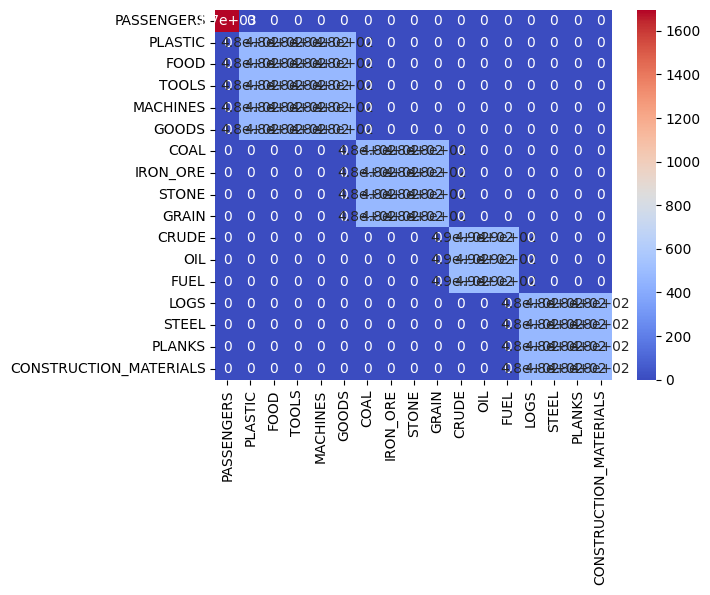

In [10]:
sns.heatmap(goods_coherence, annot=True, cmap="coolwarm")